### **Members:**
    1. Shamila Uwineza
    2. Steven Kayitare

African Leadership University

BSE - Machine Learning

Mathematics for Machine Learning

Formative Assignment: Advanced Linear Algebra (PCA)



# Introduction
This notebook contains step by step processes through the implementation of Principal Component Analysis (PCA) on the dataset that is called "**African Economy from 1980 to 2022**" (https://www.kaggle.com/datasets/mahmoudsaeed99/african-economy-from-1980-to-2022), obtained from Kaggle dataset. All outputs for each code cell are displayed and to improve the readability, before the code cells, there are the text cells (Markdown cell) that explains what the next code cells are there for. During the computation of PCA, only numpy library were used, even though other libraries such as pandas and matplotlib will be used for data manipulation and data visualization respectively.

The file used is added in the content folder that is in the same path as this notebook, for you to re-run the cells in case you want to do so. To run this notebook on your own, clone this repository and will come with the notebook and the content/file and boom.. you are all sorted to run this (Make sure you have Jupyter Notebook installed in VS code extensions, and installed Numpy, Pandas and Matplotlib).



## Importing The Necessary Libraries

---

The code cell belows import the relevant libraries including; Numpy, Pandas, and Matplotlib for use throughout this task

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

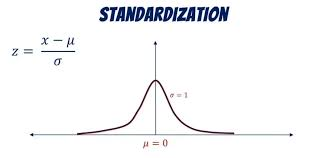


**Loading And Understanding The Dataset With Pandas**

---

The code cells below use Pandas (pd) to load the dataset, print out the dataset to understand the dataset we are working with, clearly understand the info about the dataset such as the datatype of each column, checking if there are some missing values or not. Hence, we can clean and process the dataset to make it ready for PCA analysis

In [2]:
df = pd.read_csv("content/ObservationData_lavlqce.csv")

In [3]:
df.head()

,Country,Year,Real per Capita GDP Growth Rate (annual %),Real GDP growth (annual %),"Gross domestic product, (constant prices US$)","Gross domestic product, current prices (current US$)",Final consumption expenditure (current US$),General government final consumption expenditure (current US$),Household final consumption expenditure (current US$),Gross capital formation (current US$),...,Imports of goods and services (% of GDP),"Central government, Fiscal Balance (Current US $)","Central government, total revenue and grants (Current US $)","Central government, total expenditure and net lending (Current US $)","Central government, Fiscal Balance (% of GDP)","Central government, total revenue and grants (% of GDP)","Central government, total expenditure and net lending (% of GDP)","Current account balance (Net, BoP, cur. US$)",Current account balance (As % of GDP),"Inflation, consumer prices (annual %)"
0,Malawi,1980,NaN,NaN,3038.14,2236.36,1104.30,238.76,865.54,306.24,...,21.48,-142.96,298.61,441.57,-6.39,13.35,19.75,-207.07,-9.26,NaN
1,Malawi,1981,-13.06,-10.81,2709.74,2236.40,1091.26,221.16,870.10,218.14,...,17.41,-133.47,276.61,410.09,-5.97,12.37,18.34,-86.71,-3.88,12.01
2,Malawi,1982,-0.93,1.44,2748.84,2113.68,1002.45,206.82,795.63,252.58,...,16.10,-119.21,254.71,373.92,-5.64,12.05,17.69,-91.15,-4.31,9.52
3,Malawi,1983,1.56,4.21,2864.70,2203.66,1037.06,200.81,836.26,278.87,...,15.73,-96.80,250.68,347.48,-4.39,11.38,15.77,-103.94,-4.72,13.77
4,Malawi,1984,0.54,3.92,2976.95,2157.88,1028.95,189.62,839.34,155.58,...,14.79,-78.94,239.30,318.24,-3.66,11.09,14.75,3.88,0.18,19.74


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2322 entries, 0 to 2321
Data columns (total 31 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Country                                                                2322 non-null   str    
 1   Year                                                                   2322 non-null   int64  
 2   Real per Capita GDP Growth Rate (annual %)                             2238 non-null   float64
 3   Real GDP growth (annual %)                                             2238 non-null   float64
 4   Gross domestic product, (constant prices US$)                          2292 non-null   float64
 5   Gross domestic product, current prices (current US$)                   2311 non-null   float64
 6   Final consumption expenditure  (current US$)                           2239 non-null   float64
 7  

In [5]:
df.describe()

,Year,Real per Capita GDP Growth Rate (annual %),Real GDP growth (annual %),"Gross domestic product, (constant prices US$)","Gross domestic product, current prices (current US$)",Final consumption expenditure (current US$),General government final consumption expenditure (current US$),Household final consumption expenditure (current US$),Gross capital formation (current US$),"Gross capital formation, Private sector (current US$)",...,Imports of goods and services (% of GDP),"Central government, Fiscal Balance (Current US $)","Central government, total revenue and grants (Current US $)","Central government, total expenditure and net lending (Current US $)","Central government, Fiscal Balance (% of GDP)","Central government, total revenue and grants (% of GDP)","Central government, total expenditure and net lending (% of GDP)","Current account balance (Net, BoP, cur. US$)",Current account balance (As % of GDP),"Inflation, consumer prices (annual %)"
count,2322.000000,2238.000000,2238.000000,2292.000000,2311.000000,2239.000000,2239.000000,2239.000000,2239.000000,2159.000000,...,2239.000000,2173.000000,2158.000000,2162.000000,2175.000000,2158.000000,2162.000000,2204.000000,2202.000000,2168.000000
mean,2001.000000,1.042187,3.565049,27225.223128,22701.919534,17641.202372,3190.896767,14450.305591,5232.660491,3154.609966,...,37.979088,-918.702293,5115.030002,6049.372484,-3.813014,21.711203,25.384320,-431.740119,-5.509424,12.393327
std,12.412347,8.058697,8.337714,63403.727464,56682.384991,45648.167839,8183.825011,38866.914745,12737.554775,7915.182189,...,23.566101,3842.830457,12709.412839,15212.690163,8.250077,11.723095,13.348476,3665.635861,10.203279,29.401716
min,1980.000000,-66.922658,-66.657000,104.150000,0.000000,29.820000,6.930000,21.430000,7.350000,-2301.810000,...,0.000000,-43076.459670,0.000000,0.000000,-130.797652,0.000000,0.000000,-27290.000000,-101.130000,-88.600000
25%,1990.000000,-1.187500,1.303718,2012.162500,1535.106243,1432.753480,239.220851,1162.015000,270.945000,116.180000,...,23.423166,-558.644959,327.782500,386.152500,-5.790000,14.460143,17.670257,-699.540340,-9.100000,2.633642
50%,2001.000000,1.319136,3.800000,7230.382226,5074.170000,4424.570000,734.690000,3581.740000,1005.040000,448.940000,...,31.996816,-126.240000,1064.815000,1257.750000,-3.360000,19.210000,22.705000,-178.780000,-4.765000,6.200000
75%,2012.000000,3.536522,6.025666,19132.266597,15069.510000,12128.492525,2351.524771,9797.246865,3646.024460,2026.870795,...,47.285000,-22.220000,3400.390114,3971.987060,-1.180000,26.382594,30.813857,-24.747500,-1.278961,12.402500
max,2022.000000,123.339493,124.709000,488055.765400,568498.788200,444635.630000,82709.691690,407885.104800,122579.547600,74110.593060,...,222.880000,22895.330000,113828.182200,132405.491400,124.100000,167.540000,181.951867,37087.050000,61.273577,622.751634


In [6]:
df.isna().sum()

Country                                                                    0
Year                                                                       0
Real per Capita GDP Growth Rate (annual %)                                84
Real GDP growth (annual %)                                                84
Gross domestic product, (constant prices US$)                             30
Gross domestic product, current prices (current US$)                      11
Final consumption expenditure  (current US$)                              83
General government final consumption expenditure (current US$)            83
Household final consumption expenditure (current US$)                     83
Gross capital formation (current US$)                                     83
Gross capital formation, Private sector  (current US$)                   163
Gross capital formation, Public sector  (current US$)                    163
Exports of goods and services (current US$)                               83

In [7]:
columns_with_mv = df.columns[df.isna().sum() > 0]
columns_with_mv = columns_with_mv.to_list()
print(f"There are {len(columns_with_mv)} columns with missing values.")

There are 29 columns with missing values.


## **Summarized Findings On The Dataset And Key Decision Made**
---


The dataset is of a shape (2322, 31) from which only one column (Country) is non-numerical data type, and around 29 columns contain some missing values. Since the PCA analysis requires the data to be numerical and be complete without any missing values, we decided to dropp off the Country column as it has no meaning contribution on the data, it is just an indicator We actually thought of converting it to numerical with **pandas.get_dummies()**, however, it'd make no sense becuase that'd be misleading the process, making the PCA takes it as if it is making any contribution on the dataset.

For the missing values, we handled that by replacing them with the mean value of respective column. 
The code cells below are fill out the missing values with the mean value respectively, and dropping the unnecessary column called "Country" for the PCA.

In [8]:

df = df.fillna(df.mean(numeric_only=True))

In [9]:
df.isna().sum()

Country                                                                  0
Year                                                                     0
Real per Capita GDP Growth Rate (annual %)                               0
Real GDP growth (annual %)                                               0
Gross domestic product, (constant prices US$)                            0
Gross domestic product, current prices (current US$)                     0
Final consumption expenditure  (current US$)                             0
General government final consumption expenditure (current US$)           0
Household final consumption expenditure (current US$)                    0
Gross capital formation (current US$)                                    0
Gross capital formation, Private sector  (current US$)                   0
Gross capital formation, Public sector  (current US$)                    0
Exports of goods and services (current US$)                              0
Imports of goods and serv

In [10]:
country_col = df["Country"]

In [11]:
df = df.drop("Country", axis=1)

## **New Transformed Dataset**
---

Viewing and understanding the new transformed dataset ready for the PCA analysis, with all numeric data and no missing values

In [12]:
df.head()

,Year,Real per Capita GDP Growth Rate (annual %),Real GDP growth (annual %),"Gross domestic product, (constant prices US$)","Gross domestic product, current prices (current US$)",Final consumption expenditure (current US$),General government final consumption expenditure (current US$),Household final consumption expenditure (current US$),Gross capital formation (current US$),"Gross capital formation, Private sector (current US$)",...,Imports of goods and services (% of GDP),"Central government, Fiscal Balance (Current US $)","Central government, total revenue and grants (Current US $)","Central government, total expenditure and net lending (Current US $)","Central government, Fiscal Balance (% of GDP)","Central government, total revenue and grants (% of GDP)","Central government, total expenditure and net lending (% of GDP)","Current account balance (Net, BoP, cur. US$)",Current account balance (As % of GDP),"Inflation, consumer prices (annual %)"
0,1980,1.042187,3.565049,3038.14,2236.36,1104.30,238.76,865.54,306.24,90.26,...,21.48,-142.96,298.61,441.57,-6.39,13.35,19.75,-207.07,-9.26,12.393327
1,1981,-13.060000,-10.810000,2709.74,2236.40,1091.26,221.16,870.10,218.14,91.70,...,17.41,-133.47,276.61,410.09,-5.97,12.37,18.34,-86.71,-3.88,12.010000
2,1982,-0.930000,1.440000,2748.84,2113.68,1002.45,206.82,795.63,252.58,153.01,...,16.10,-119.21,254.71,373.92,-5.64,12.05,17.69,-91.15,-4.31,9.520000
3,1983,1.560000,4.210000,2864.70,2203.66,1037.06,200.81,836.26,278.87,176.89,...,15.73,-96.80,250.68,347.48,-4.39,11.38,15.77,-103.94,-4.72,13.770000
4,1984,0.540000,3.920000,2976.95,2157.88,1028.95,189.62,839.34,155.58,37.64,...,14.79,-78.94,239.30,318.24,-3.66,11.09,14.75,3.88,0.18,19.740000


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2322 entries, 0 to 2321
Data columns (total 30 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Year                                                                   2322 non-null   int64  
 1   Real per Capita GDP Growth Rate (annual %)                             2322 non-null   float64
 2   Real GDP growth (annual %)                                             2322 non-null   float64
 3   Gross domestic product, (constant prices US$)                          2322 non-null   float64
 4   Gross domestic product, current prices (current US$)                   2322 non-null   float64
 5   Final consumption expenditure  (current US$)                           2322 non-null   float64
 6   General government final consumption expenditure (current US$)         2322 non-null   float64
 7  

## **Standardizing Data**
---
Finally dataset is ready to start the PCA, and the code cell below perform the data standardization following the formula as shown in the above text cells earlier.

In [14]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
# Formula to be used, Z = (x - m)/std

# Ensure all columns are numeric before converting to numpy array
df_numeric = df.astype(float)
df_np = df_numeric.to_numpy()

# df_np.shape
mean = np.mean(df_np, axis=0)
# mean
std = np.std(df_np, axis=0)
# print(std)
standardized_data = (df_np - mean) / std
standardized_data[:5]  # Display the first few rows of standardized data

array([[-1.69222822,  0.        ,  0.        , -0.38404956, -0.36199338,
        -0.36900468, -0.36743558, -0.35601898, -0.39395488, -0.40158995,
        -0.3288848 , -0.41302626, -0.43432464, -1.36824738, -0.60878942,
        -1.23212277, -0.67919714, -0.87038706,  0.0258651 , -0.74542515,
        -0.71313751,  0.20872162, -0.3931922 , -0.38211177, -0.32281631,
        -0.74000136, -0.43753575,  0.06292451, -0.37755419,  0.        ],
       [-1.61164593, -1.78287028, -1.75654968, -0.38926399, -0.36199267,
        -0.36929566, -0.36962615, -0.35589947, -0.40100004, -0.40140123,
        -0.34394684, -0.41231193, -0.44078181, -1.39340534, -0.71780174,
        -1.22258627, -1.04890016, -0.86340193, -0.46401486, -0.72226683,
        -0.88905448,  0.21127501, -0.39498819, -0.38425679, -0.27020336,
        -0.82673545, -0.54702996,  0.09663435,  0.16402705, -0.0134958 ],
       [-1.53106363, -0.24933395, -0.25966898, -0.38864315, -0.36416333,
        -0.37127737, -0.37141097, -0.35785112, -0

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [15]:
standardized_data.T.shape

(30, 2322)

In [16]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data.T)  # Calculate covariance matrix
cov_matrix.shape

(30, 30)

## **DIscussion - Answers To The Questions**
---

**Explain why we need to compute a covariance matrix, provide atleast 2 reasons**

PCA analyzes the features to reduce the dimensionality of the data while preserving the necessary information. Therefore, PCA needs to exploit the the features that have linear relationship with the help of Covariance so that they can be reduced to one axis. Covariance matrix also provides the variance spread across all feature combinations, and it also helps to compute the eigendecomposition. Without it, we have no mathematical basis for identifying which combinations of economic indicators carry the most information, making dimensionality reduction impossible.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [17]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)  # Perform eigendecomposition
eigenvalues, eigenvectors

(array([1.11137468e+01, 3.99216849e+00, 2.83756053e+00, 2.16168759e+00,
        1.57125981e+00, 1.43758321e+00, 1.22924642e+00, 9.63346304e-01,
        8.86635673e-01, 7.44510417e-01, 6.27821016e-01, 4.96035315e-01,
        4.75160510e-01, 3.99373577e-01, 3.36819634e-01, 2.06237340e-01,
        1.61345634e-01, 1.05483020e-01, 7.29575960e-02, 6.08429355e-02,
        4.85027456e-02, 3.44290744e-02, 2.00803790e-02, 1.12323355e-02,
        9.36483347e-03, 7.04970856e-03, 1.63926254e-03, 8.05275842e-04,
        1.54342294e-08, 5.29498410e-15]),
 array([[ 8.32159872e-02,  1.18604251e-01,  5.19964845e-02,
          2.34013387e-01, -6.87168277e-02, -3.18100348e-01,
          1.38044480e-01, -9.73419304e-02, -2.31992785e-01,
         -7.96195059e-01, -3.62909403e-04,  1.85754376e-01,
          2.03855870e-02,  1.98151323e-01, -4.18517851e-02,
          5.03900382e-02, -3.33943066e-02,  1.20289790e-01,
          6.08822161e-02,  2.41721641e-02, -1.07123821e-02,
         -1.19511116e-02, -9.68341

In [18]:
eigenvalues.shape, eigenvectors.shape

((30,), (30, 30))

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [28]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]  # will be needed for explained variance calculation
sorted_eigenvectors = eigenvectors[:, sorted_indices] # Sort eigenvectors accordingly
sorted_eigenvectors 

array([[ 8.32159872e-02,  1.18604251e-01,  5.19964845e-02,
         2.34013387e-01, -6.87168277e-02, -3.18100348e-01,
         1.38044480e-01, -9.73419304e-02, -2.31992785e-01,
        -7.96195059e-01, -3.62909403e-04,  1.85754376e-01,
         2.03855870e-02,  1.98151323e-01, -4.18517851e-02,
         5.03900382e-02, -3.33943066e-02,  1.20289790e-01,
         6.08822161e-02,  2.41721641e-02, -1.07123821e-02,
        -1.19511116e-02, -9.68341420e-03,  1.19599635e-02,
        -1.84846683e-02, -1.27855584e-02, -1.73929064e-03,
        -2.30933070e-04, -1.47907090e-06, -3.50481505e-09],
       [ 3.89582662e-03,  8.66261261e-02, -2.87601419e-01,
         4.50612119e-01,  1.74201740e-01,  4.04027535e-01,
        -3.84895081e-02, -2.81710333e-02, -7.78618360e-02,
        -3.39749269e-02,  3.64485359e-02,  2.63766371e-02,
         2.42991502e-02, -1.00147071e-02, -2.58413598e-02,
        -1.07639284e-02,  4.08826469e-03,  2.65707663e-02,
         1.84490766e-02, -7.55567099e-03, -1.95924560e-

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [30]:
# Explained Variance Ratio per Principal Component
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

for i, (ev, cv) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
    print(f"PC{i+1:2d}: {ev*100:.2f}%  |  Cumulative: {cv*100:.2f}%")


PC 1: 37.03%  |  Cumulative: 37.03%
PC 2: 13.30%  |  Cumulative: 50.33%
PC 3: 9.45%  |  Cumulative: 59.79%
PC 4: 7.20%  |  Cumulative: 66.99%
PC 5: 5.24%  |  Cumulative: 72.22%
PC 6: 4.79%  |  Cumulative: 77.01%
PC 7: 4.10%  |  Cumulative: 81.11%
PC 8: 3.21%  |  Cumulative: 84.32%
PC 9: 2.95%  |  Cumulative: 87.27%
PC10: 2.48%  |  Cumulative: 89.75%
PC11: 2.09%  |  Cumulative: 91.85%
PC12: 1.65%  |  Cumulative: 93.50%
PC13: 1.58%  |  Cumulative: 95.08%
PC14: 1.33%  |  Cumulative: 96.41%
PC15: 1.12%  |  Cumulative: 97.53%
PC16: 0.69%  |  Cumulative: 98.22%
PC17: 0.54%  |  Cumulative: 98.76%
PC18: 0.35%  |  Cumulative: 99.11%
PC19: 0.24%  |  Cumulative: 99.35%
PC20: 0.20%  |  Cumulative: 99.56%
PC21: 0.16%  |  Cumulative: 99.72%
PC22: 0.11%  |  Cumulative: 99.83%
PC23: 0.07%  |  Cumulative: 99.90%
PC24: 0.04%  |  Cumulative: 99.94%
PC25: 0.03%  |  Cumulative: 99.97%
PC26: 0.02%  |  Cumulative: 99.99%
PC27: 0.01%  |  Cumulative: 100.00%
PC28: 0.00%  |  Cumulative: 100.00%
PC29: 0.00%  |  

In [43]:
# Dynamically select components that explain at least 95% of variance
threshold = 0.95
num_components = int(np.argmax(cumulative_variance >= threshold) + 1)
print(f"Components needed to explain {threshold*100:.0f}% of variance: {num_components}")
print(f"Actual variance retained: {cumulative_variance[num_components-1]*100:.2f}%")


Components needed to explain 95% of variance: 13
Actual variance retained: 95.08%


In [45]:
sorted_eigenvectors[:, :num_components].shape

(30, 13)

In [47]:
# Step 6: Project Data onto Principal Components
reduced_data =  np.dot(standardized_data, sorted_eigenvectors[:, :num_components]) # Project data onto the principal components

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [48]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (2322, 13)


array([[-1.47897086, -1.92545585, -0.64725054, -1.02361606,  1.12340644,
         0.53211494, -1.22590043, -0.35588981,  0.49703139,  0.81538214,
         0.13622094,  0.23060235, -0.15552148],
       [-1.48738764, -2.71077104,  0.16371872, -2.7204621 ,  0.21836465,
        -0.73251987, -0.65609904, -0.35956906,  0.50278995,  0.74254337,
         0.06254381, -0.0247021 , -0.19280851],
       [-1.45392258, -2.40905471, -0.76093099, -1.34455431,  1.0556834 ,
         0.35609518, -0.49095032, -0.38949841,  0.42490468,  0.59883449,
         0.11521961,  0.06610071, -0.05642952],
       [-1.45023651, -2.45564939, -0.98101261, -0.92824293,  1.25257626,
         0.45880462, -0.47573536, -0.23749912,  0.330092  ,  0.5670716 ,
         0.0384905 ,  0.10258645, -0.03273864],
       [-1.49404628, -2.88341927, -1.11185979, -0.99982826,  0.53979942,
         0.51057437, -0.89414984, -0.39901098, -0.12257237,  0.43968463,
         0.08831322, -0.00385838, -0.06813913]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

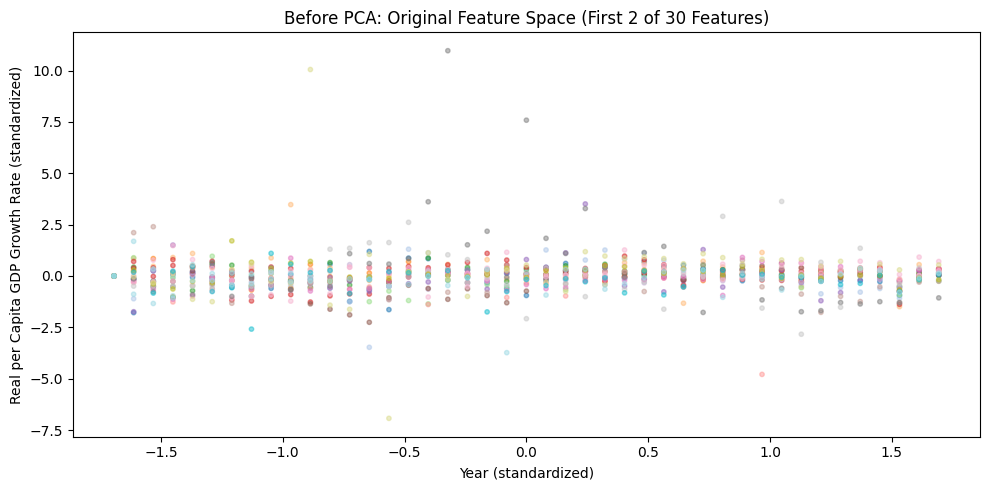

In [54]:
# Step 8: Before PCA
# Plot of the original data (first two features for simplicity)
unique_countries = country_col.unique()
color_map = {c: i for i, c in enumerate(unique_countries)}
point_colors = [color_map[c] for c in country_col]

plt.figure(figsize=(10, 5))
plt.scatter(standardized_data[:1000, 0], standardized_data[:1000, 1],
            c=point_colors[:1000], cmap='tab20', alpha=0.5, s=10)
plt.xlabel('Year (standardized)')
plt.ylabel('Real per Capita GDP Growth Rate (standardized)')
plt.title('Before PCA: Original Feature Space (First 2 of 30 Features)')
plt.tight_layout()
plt.show()


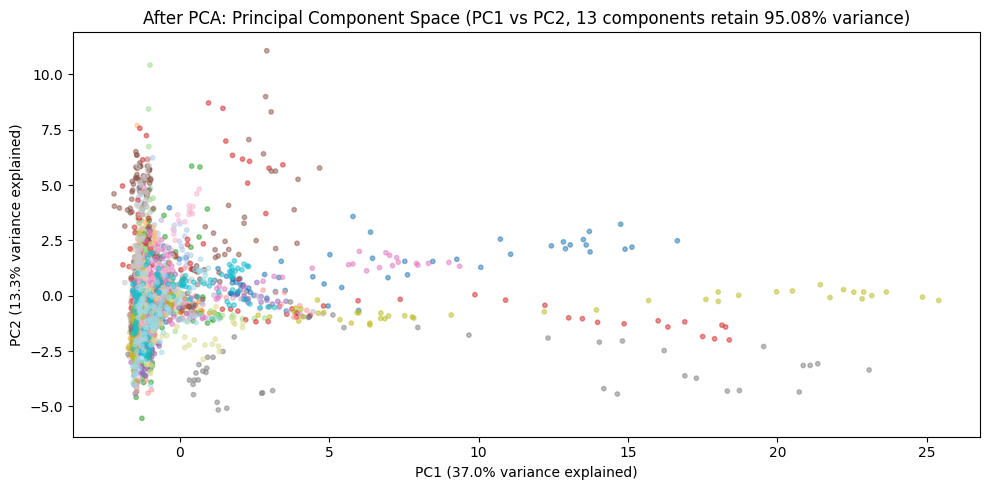

In [50]:
# Step 8: After PCA
# Plot reduced data after PCA (first two principal components)
plt.figure(figsize=(10, 5))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1],
            c=point_colors, cmap='tab20', alpha=0.5, s=10)
plt.xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance explained)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance explained)')
plt.title('After PCA: Principal Component Space (PC1 vs PC2, 13 components retain 95.08% variance)')
plt.tight_layout()
plt.show()


## **Discussion - Answers To The Questions**
---

**1. Interpret the Visual you just created of the before and after PCA**

Before PCA, the scatter plot shows a vertical bands, where year seems to move linearly on the x-axis. each vertical stack at a given year contains all 54 countries at that same point in time.

**2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making**

Basically, we selected 13 because, that was the number of PCAs that, when cumulatively summed from the most to least, hit 95% total variance (95.08%). The tradeoffs that we made: we dropped off 17 components which hold 4.92% together therefore, we reduced the dimensionality well while keeping the 95% of the information.

**3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?**

On our use case, we dropped 4.92%, that contains low-variance country-specific signals, small fiscal balance differences between neighbouring countries, short-term inflation spikes in individual nations, and minor trade ratio fluctuations. In practical terms: a country with a unique but low-magnitude economic history (e.g. a small post-conflict recovery) may become indistinguishable from its neighbours in the reduced space.
